# Fourth Trial Set: Z-Score Cluster Scoring

Z-Score scoring applied to the full Fourth Trial Set (`Fourth_Trial_Set_PDM_Rezepturen_Gesamt_28-07-2026.xlsx`).

Pipeline:
1. Load recipes from "Rezepte Gesamt AJ" sheet; resolve CAS numbers via "CAS Nr." lookup
2. Zero out carrier/solvent substances listed in "Normalisierung" sheet (167 substances)
3. Normalize ingredient amounts per recipe (sum to 1)
4. Apply Z-Score: replace normalized amount with amount / AvgMeli per CAS (Melanie reference)
5. Score each recipe against 7 clusters using the updated Scoring Index weight matrix
6. Assign each recipe to the argmax cluster


## Scoring Methods: How Each Run Is Calculated

All four methods share the same preprocessing pipeline before scoring begins.

### Shared Preprocessing

**Step 1: Load ingredients**
Read all ingredient rows from the "Rezepte Gesamt AJ" sheet. Each row contains a recipe ID,
an ingredient identifier (Ident), and a raw amount (Totalmenge). CAS numbers are resolved by
joining on the "CAS Nr." sheet.

**Step 2: Zero out carriers and solvents**
The "Normalisierung" sheet lists 167 substances (Propylenglycol, Ethanol, Glycerin, etc.)
that are functional carriers, not flavour-active. Their Totalmenge is set to 0 before any
further calculation.

**Step 3: Normalize per recipe**
After zeroing out carriers, each recipe's remaining amounts are rescaled so they sum to 1:

```
norm_amount[CAS] = Totalmenge[CAS] / sum(Totalmenge per recipe)
```

This makes recipes comparable regardless of their absolute batch size.

**Step 4: Score against weight matrix**
The Scoring Index sheet assigns each CAS a weight (0-20) per cluster
(Unpleasant, warm, green, floral, citrus, exotic, Outlayer).
The raw score for a recipe in a cluster is:

```
Score[cluster] = sum(weight[CAS][cluster] x amount[CAS])   for all CAS
```

The predicted cluster is the one with the highest score (argmax).

---

### Method 1: Raw MS (weight matrix only)

Uses normalized amounts directly:

```
amount[CAS] = norm_amount[CAS]
```

Every CAS contributes in proportion to its share of the recipe.
No calibration against any reference. 94.5% CAS coverage (only CAS missing from the
weight matrix contribute 0).

---

### Method 2: Z-Score Meli (Melanie's calibration)

Replaces the normalized amount with a ratio against Melanie's reference baseline:

```
amount[CAS] = norm_amount[CAS] / AvgMeli[CAS]
```

AvgMeli[CAS] is the mean normalized amount of that CAS across Melanie's 9 strawberry
reference recipes, counting only the recipes where the ingredient is present.
A Z-Score of 2 means the ingredient is present at twice its typical concentration in
Melanie's reference set.

CAS with no AvgMeli entry are zeroed out. Because the reference set is strawberry-only,
only 30.7% of the CAS in the Fourth Trial Set have a valid AvgMeli.

---

### Method 3: Z-Score Self-Average

Same formula, but the baseline is computed from the Fourth Trial Set itself:

```
AvgSelf[CAS] = mean(norm_amount[CAS]) across all recipes where CAS is present
amount[CAS]  = norm_amount[CAS] / AvgSelf[CAS]
```

A Z-Score of 2 means the ingredient is present at twice its typical concentration in
this dataset. Coverage: 94.5% of CAS.

---

### Method 4: Z-Score Self-Median

Identical to Method 3 but uses the median instead of the mean as the baseline:

```
MedianSelf[CAS] = median(norm_amount[CAS]) across all recipes where CAS is present
amount[CAS]     = norm_amount[CAS] / MedianSelf[CAS]
```

The median is less sensitive to extreme values. A small number of recipes using an
ingredient at a very high concentration will inflate the mean baseline, reducing its
Z-Score contribution. The median stays closer to the typical usage level.
Coverage: 94.5% of CAS.


In [1]:
import sys
sys.path.insert(0, "../scripts")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 120

from pathlib import Path
from ms_scoring import (
    load_fourth_trial_recipes,
    load_fourth_trial_weight_matrix,
    load_avg_meli,
    apply_zscore_quantities,
    compute_scores,
    normalize_scores,
    assign_clusters,
    CLUSTER_COLS,
)

FOURTH_TRIAL = Path("../data/gold/Fourth_Trial_Set_PDM_Rezepturen_Gesamt_28-07-2026.xlsx")
OLD_SCORING  = Path("../data/gold/Scoring Index_Beispielrechung.xlsx")
OUT_XLSX     = Path("../outputs/scoring_fourth_trial.xlsx")
OUT_PLOT     = Path("../outputs/fourth_trial_score_profiles.png")

MS_TO_PANEL = {
    "warm":       "warm",
    "Unpleasant": "unpleasant",
    "green":      "green",
    "floral":     "floral",
    "citrus":     "fruity",
}


## 1. Load Recipes

In [2]:
recipes = load_fourth_trial_recipes(FOURTH_TRIAL)

n_recipes = recipes["Rez.-Nr."].nunique()
n_rows    = len(recipes)
n_cas     = recipes["CAS-Nr."].nunique()

print(f"Recipes loaded: {n_recipes}")
print(f"Ingredient rows: {n_rows:,}")
print(f"Unique CAS numbers: {n_cas}")
print()
print("Sample rows:")
print(recipes.head(5).to_string(index=False))


INFO: 4684 ingredient rows have no CAS-Nr. match and are dropped
Recipes loaded: 6392
Ingredient rows: 141,033
Unique CAS numbers: 726

Sample rows:
Rez.-Nr.   CAS-Nr.  Totalmenge
 185.046 8022-96-6    0.001965
 185.046  110-43-0    0.019646
 185.046  116-53-0    0.086444
 185.046  109-21-7    0.145383
 185.046  928-96-1    0.440079


## 2. Weight Matrix (Scoring Index)

In [3]:
weights = load_fourth_trial_weight_matrix(FOURTH_TRIAL)

print(f"Weight matrix: {weights.shape[0]} CAS x {weights.shape[1]} clusters")
print()
print("Column sums (total weight capacity per cluster):")
print(weights.sum().to_string())
print()
print("Top 5 rows:")
print(weights[weights.sum(axis=1) > 0].head(5).to_string())


Weight matrix: 224 CAS x 7 clusters

Column sums (total weight capacity per cluster):
Unpleasant    114
warm          256
green          72
floral        225
citrus         78
exotic         39
Outlayer       66

Top 5 rows:
            Unpleasant  warm  green  floral  citrus  exotic  Outlayer
CAS                                                                  
14667-55-1           3     3      0       0       0       0         3
116-53-0             2     2      0       0       2       2         0
7786-61-0            3     0      0       0       0       0         0
75-07-0              3     0      0       0       0       0         0
3390-12-3            3     0      0       0       0       0         0


## 3. AvgMeli Reference (Melanie's Calibration)

In [4]:
avg_meli = load_avg_meli(OLD_SCORING, csv_path=None)

print(f"AvgMeli entries: {len(avg_meli)}")
print()

# Coverage: how many recipe CAS have a valid AvgMeli?
recipe_cas = set(recipes["CAS-Nr."].unique())
covered = recipe_cas & set(avg_meli[avg_meli > 0].index)
print(f"Recipe CAS with valid AvgMeli: {len(covered)} / {len(recipe_cas)} "
      f"({100 * len(covered) / len(recipe_cas):.1f}%)")
print()
print("Note: CAS without AvgMeli contribute 0 to the Z-Score (zeroed out by apply_zscore_quantities).")


AvgMeli entries: 224

Recipe CAS with valid AvgMeli: 216 / 726 (29.8%)

Note: CAS without AvgMeli contribute 0 to the Z-Score (zeroed out by apply_zscore_quantities).


**Coverage note:** Only ~30% of the CAS numbers in the Fourth Trial Set have a valid AvgMeli entry from Melanie's reference file. The remaining CAS are zeroed out by the Z-Score transform and contribute nothing to the scores.

This is expected: Melanie's AvgMeli was calibrated on strawberry reference recipes, while the Fourth Trial Set covers all aroma types. Cluster assignments for non-strawberry recipes therefore rely primarily on the weight matrix rather than the Z-Score calibration. Results should be treated as indicative and validated against panel tastings where possible.

## 4. Z-Score Scoring

In [5]:
recipes_z = apply_zscore_quantities(recipes, avg_meli)
scores_z  = compute_scores(recipes_z, weights)
ms_z      = assign_clusters(scores_z)

print("Cluster distribution (Z-Score):")
dist = ms_z.value_counts().rename("count")
dist["total"] = dist.sum()
print(dist.to_string())
print()
print(f"Recipes with a valid Z-Score assignment: {ms_z.notna().sum()}")


Cluster distribution (Z-Score):
MS_cluster
floral        2258
warm          1563
green          863
Unpleasant     688
citrus         608
exotic         235
Outlayer       177
total         6392

Recipes with a valid Z-Score assignment: 6392


## 5. Score Profiles per Cluster

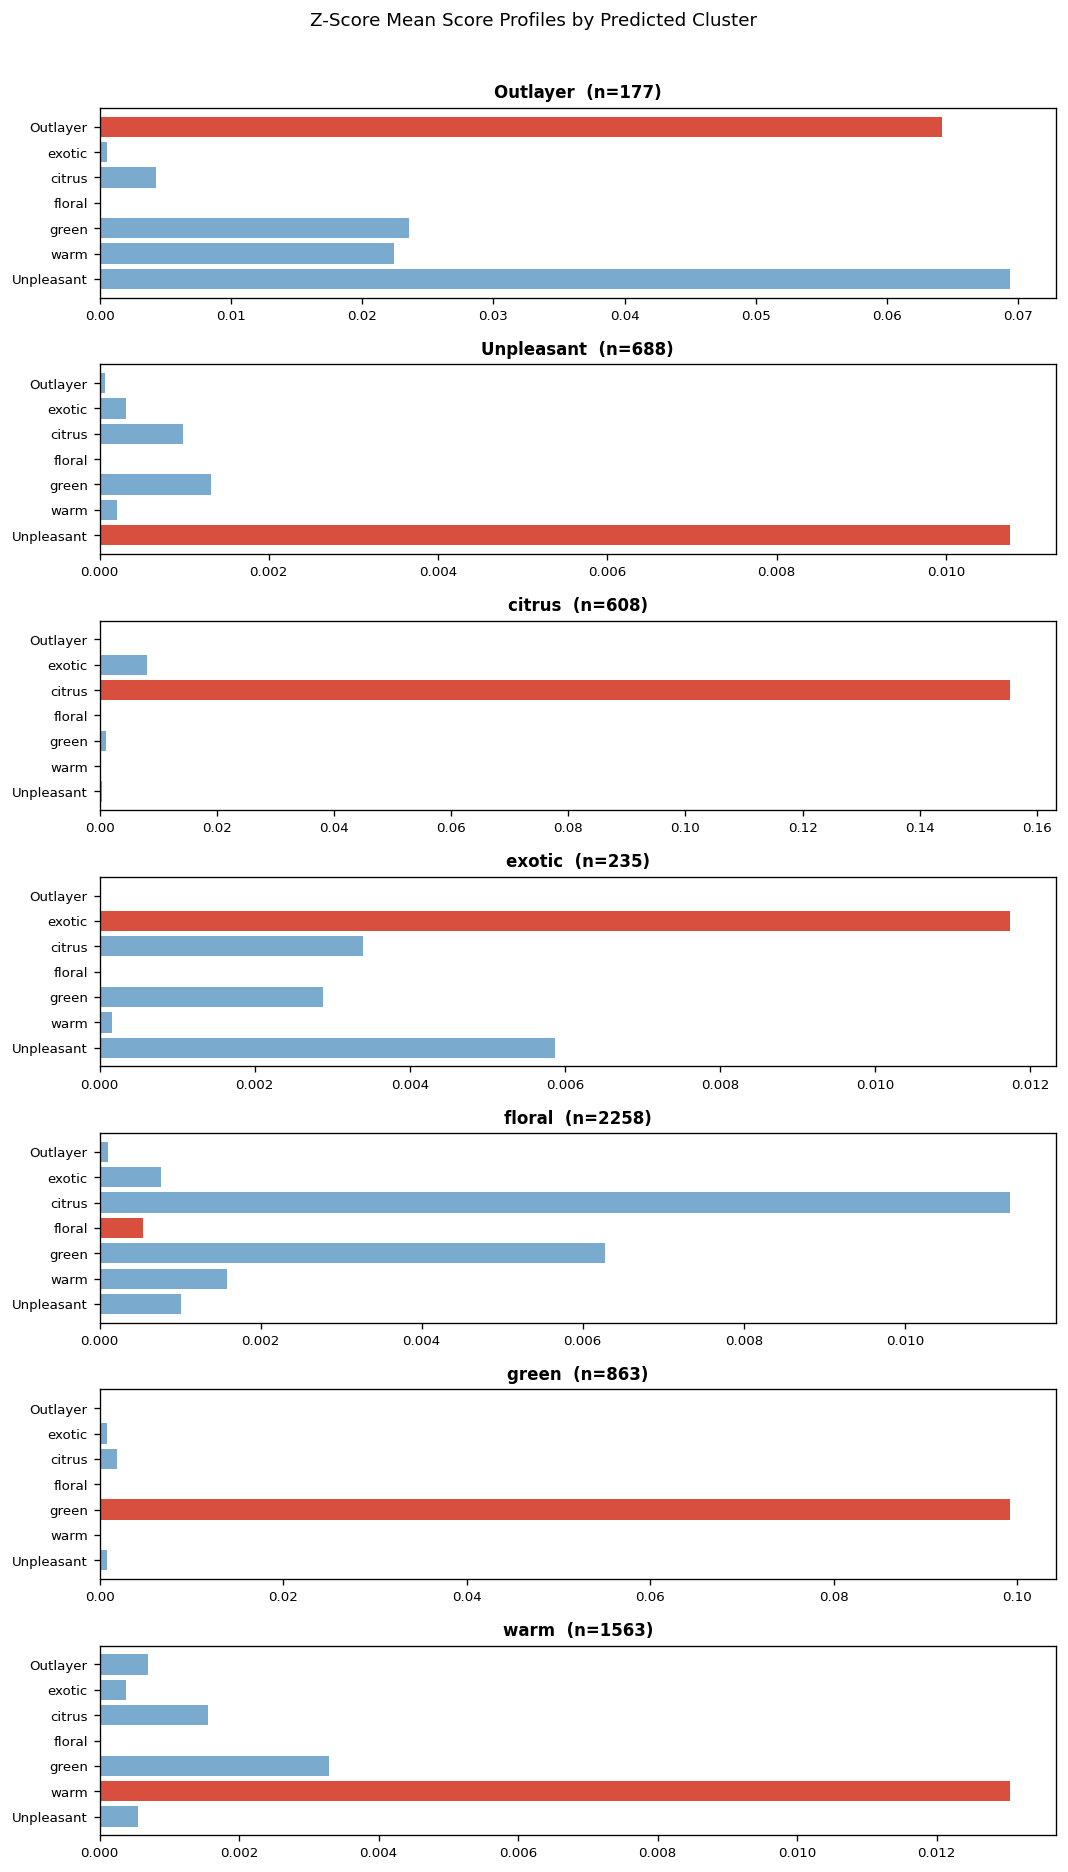

Saved: ../outputs/fourth_trial_score_profiles.png


In [6]:
scores_z_norm = normalize_scores(scores_z)

# Compute mean normalized profile per predicted cluster
profile = scores_z_norm.copy()
profile["cluster"] = ms_z
mean_profile = profile.groupby("cluster")[CLUSTER_COLS].mean()

fig, axes = plt.subplots(len(mean_profile), 1, figsize=(9, 2.2 * len(mean_profile)), sharey=False)
if len(mean_profile) == 1:
    axes = [axes]

for ax, (cluster, row) in zip(axes, mean_profile.iterrows()):
    n = (ms_z == cluster).sum()
    colors = ["#d94f3d" if c == cluster else "#7aabcf" for c in CLUSTER_COLS]
    ax.barh(CLUSTER_COLS, row[CLUSTER_COLS], color=colors)
    ax.set_xlim(0, None)
    ax.set_title(f"{cluster}  (n={n})", fontsize=10, fontweight="bold")
    ax.tick_params(axis="both", labelsize=8)

fig.suptitle("Z-Score Mean Score Profiles by Predicted Cluster", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUT_PLOT, bbox_inches="tight")
plt.show()
print(f"Saved: {OUT_PLOT}")


## 6. Export Predictions

In [7]:
ms_z_panel = ms_z.map(MS_TO_PANEL)

pred_all = pd.DataFrame({
    "ZScore_cluster":    ms_z,
    "ZScore_panel_name": ms_z_panel,
}).join(scores_z.round(4).add_prefix("Score_"))
pred_all = pred_all.sort_values("ZScore_cluster")

print(f"Total recipes exported: {len(pred_all)}")
print()
print("Cluster distribution:")
print(pred_all["ZScore_cluster"].value_counts().to_string())
print()
print("Panel-equivalent distribution (where mapped):")
print(pred_all["ZScore_panel_name"].value_counts().to_string())

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl") as writer:
    pred_all.to_excel(writer, sheet_name="ZScore_All_Predictions")
    slim = pred_all[["ZScore_cluster", "ZScore_panel_name"]].copy()
    slim.index.name = "Recipe"
    slim.to_excel(writer, sheet_name="ZScore_Predictions_Slim")

print()
print(f"Saved: {OUT_XLSX}")
print("Sheets: ZScore_All_Predictions, ZScore_Predictions_Slim")
print("Note: ZScore_panel_name is the model prediction in panel vocabulary, not a panel assessment.")


Total recipes exported: 6392

Cluster distribution:
ZScore_cluster
floral        2258
warm          1563
green          863
Unpleasant     688
citrus         608
exotic         235
Outlayer       177

Panel-equivalent distribution (where mapped):
ZScore_panel_name
floral        2258
warm          1563
green          863
unpleasant     688
fruity         608



Saved: ../outputs/scoring_fourth_trial.xlsx
Sheets: ZScore_All_Predictions, ZScore_Predictions_Slim
Note: ZScore_panel_name is the model prediction in panel vocabulary, not a panel assessment.


## 7. Raw MS Scoring (Weight Matrix Only)

Instead of dividing by AvgMeli, use the normalized ingredient amounts directly.
Every recipe and every CAS is treated equally: no calibration against reference recipes.
This gives consistent coverage across all 6,392 recipes regardless of aroma type.

In [8]:
scores_ms  = compute_scores(recipes, weights)
ms_raw     = assign_clusters(scores_ms)
ms_raw_panel = ms_raw.map(MS_TO_PANEL)

print("Cluster distribution (raw MS, weight matrix only):")
dist_ms = ms_raw.value_counts().rename("count")
print(dist_ms.to_string())
print()

# Side-by-side comparison
comp = pd.DataFrame({
    "MS_raw": ms_raw.value_counts(),
    "Z-Score": ms_z.value_counts(),
}).fillna(0).astype(int).sort_index()
comp["diff"] = comp["MS_raw"] - comp["Z-Score"]
print("Comparison vs Z-Score:")
print(comp.to_string())


Cluster distribution (raw MS, weight matrix only):
MS_cluster
warm          2396
green         1034
floral         896
Unpleasant     765
citrus         756
exotic         460
Outlayer        85

Comparison vs Z-Score:
            MS_raw  Z-Score  diff
MS_cluster                       
Outlayer        85      177   -92
Unpleasant     765      688    77
citrus         756      608   148
exotic         460      235   225
floral         896     2258 -1362
green         1034      863   171
warm          2396     1563   833


## 8. Score Profiles per Cluster (Raw MS)

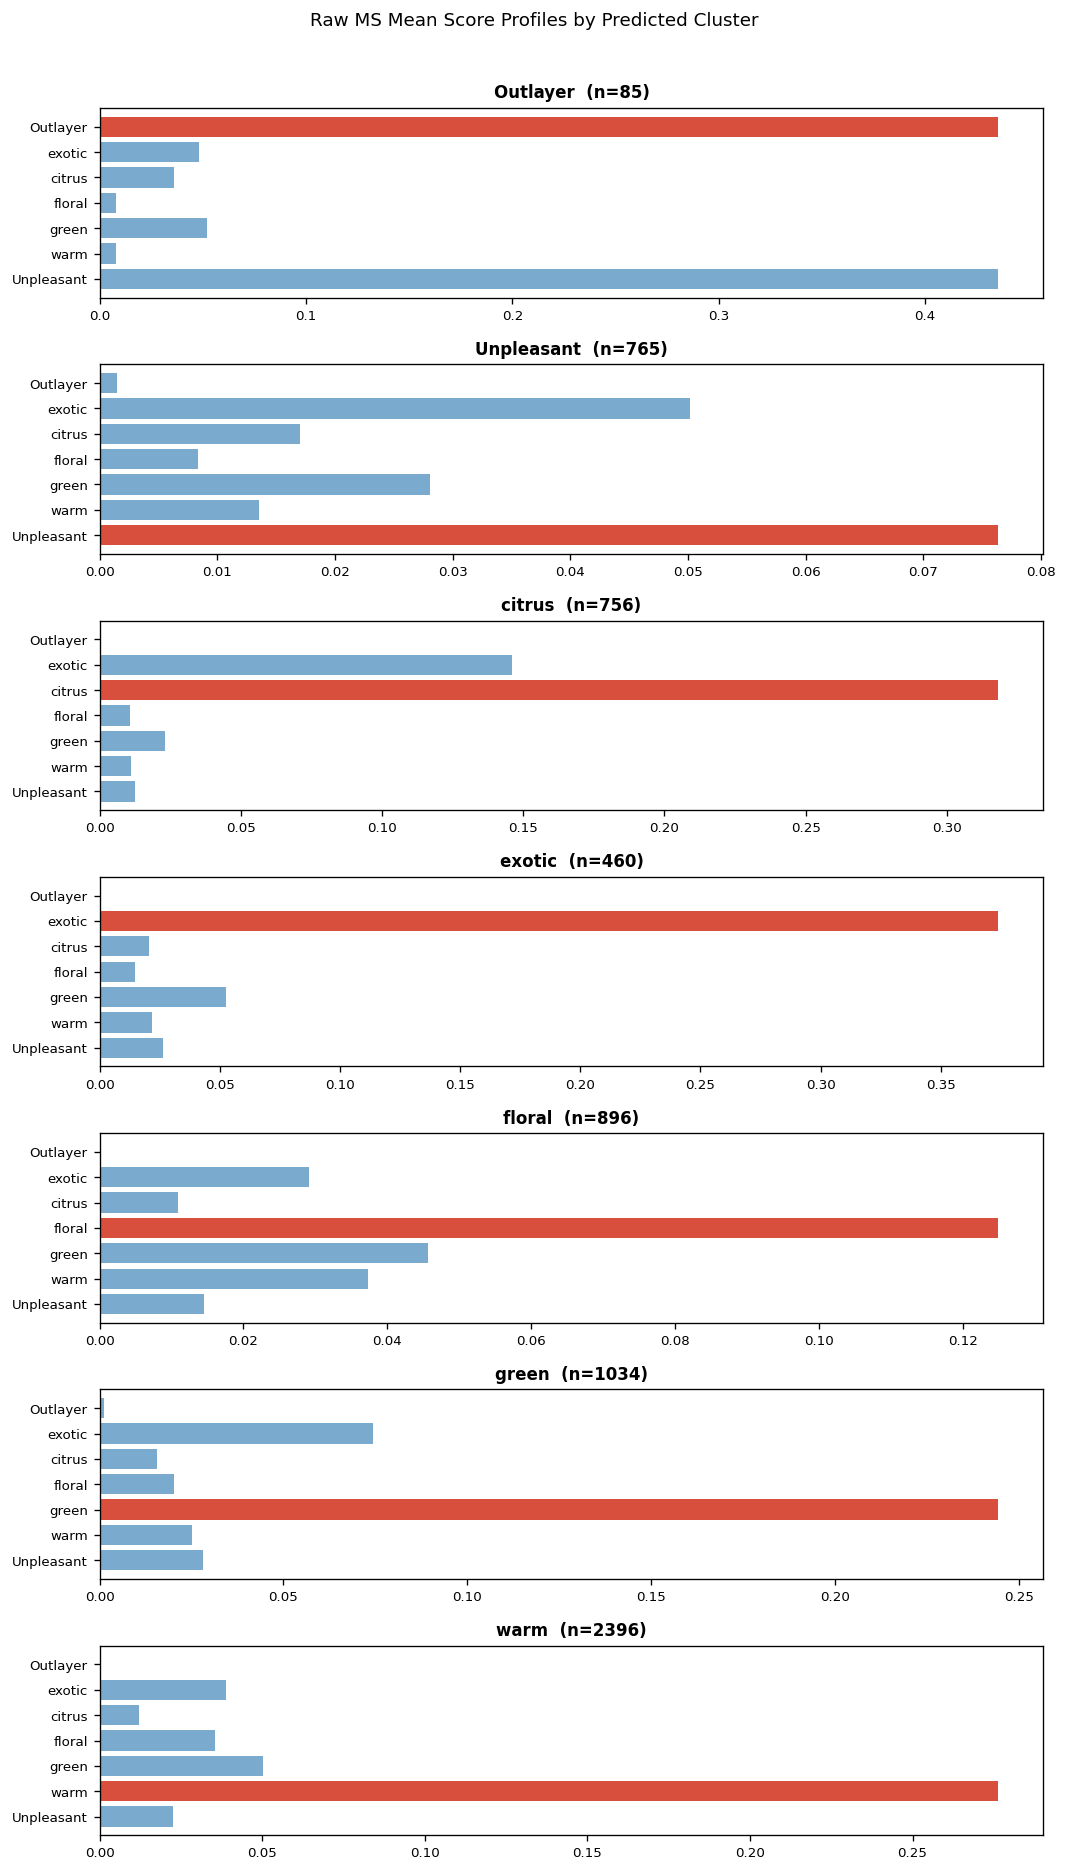

Saved: ../outputs/fourth_trial_score_profiles_ms.png


In [9]:
scores_ms_norm = normalize_scores(scores_ms)

profile_ms = scores_ms_norm.copy()
profile_ms["cluster"] = ms_raw
mean_profile_ms = profile_ms.groupby("cluster")[CLUSTER_COLS].mean()

fig, axes = plt.subplots(len(mean_profile_ms), 1,
                         figsize=(9, 2.2 * len(mean_profile_ms)), sharey=False)
if len(mean_profile_ms) == 1:
    axes = [axes]

for ax, (cluster, row) in zip(axes, mean_profile_ms.iterrows()):
    n = (ms_raw == cluster).sum()
    colors = ["#d94f3d" if c == cluster else "#7aabcf" for c in CLUSTER_COLS]
    ax.barh(CLUSTER_COLS, row[CLUSTER_COLS], color=colors)
    ax.set_xlim(0, None)
    ax.set_title(f"{cluster}  (n={n})", fontsize=10, fontweight="bold")
    ax.tick_params(axis="both", labelsize=8)

fig.suptitle("Raw MS Mean Score Profiles by Predicted Cluster", fontsize=11, y=1.01)
plt.tight_layout()

out_plot_ms = Path("../outputs/fourth_trial_score_profiles_ms.png")
plt.savefig(out_plot_ms, bbox_inches="tight")
plt.show()
print(f"Saved: {out_plot_ms}")


## 9. Export Raw MS Predictions

In [10]:
pred_ms = pd.DataFrame({
    "MS_cluster":    ms_raw,
    "MS_panel_name": ms_raw_panel,
}).join(scores_ms.round(4).add_prefix("Score_"))
pred_ms = pred_ms.sort_values("MS_cluster")

with pd.ExcelWriter(OUT_XLSX, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    pred_ms.to_excel(writer, sheet_name="MS_All_Predictions")
    slim_ms = pred_ms[["MS_cluster", "MS_panel_name"]].copy()
    slim_ms.index.name = "Recipe"
    slim_ms.to_excel(writer, sheet_name="MS_Predictions_Slim")

print(f"Added to {OUT_XLSX}:")
print("  MS_All_Predictions")
print("  MS_Predictions_Slim")
print()
print("Note: MS_panel_name is the model prediction in panel vocabulary, not a panel assessment.")


Added to ../outputs/scoring_fourth_trial.xlsx:
  MS_All_Predictions
  MS_Predictions_Slim

Note: MS_panel_name is the model prediction in panel vocabulary, not a panel assessment.


## 10. Self-Referencing Baselines (Average and Median When Present)

Instead of Melanie's 9-recipe calibration, compute the baseline directly from the
Fourth Trial Set: for each CAS, take the mean (or median) normalized amount across
all recipes where that ingredient is present (amount > 0).

This gives ~95% CAS coverage vs ~30% with Melanie's reference.

In [11]:
present = recipes[recipes["Totalmenge"] > 0]

avg_self    = present.groupby("CAS-Nr.")["Totalmenge"].mean().rename("avg_self")
median_self = present.groupby("CAS-Nr.")["Totalmenge"].median().rename("median_self")

n_cas = recipes["CAS-Nr."].nunique()
print(f"CAS in dataset:          {n_cas}")
print(f"CAS with self avg:       {len(avg_self)}  ({100*len(avg_self)/n_cas:.1f}%)")
print(f"CAS with self median:    {len(median_self)}  ({100*len(median_self)/n_cas:.1f}%)")
print(f"CAS with Meli AvgMeli:   {(avg_meli > 0).sum()}  ({100*(avg_meli > 0).sum()/n_cas:.1f}%)")
print()
print("Avg vs Median (first 10 CAS):")
comp = pd.DataFrame({"avg": avg_self, "median": median_self}).head(10)
print(comp.to_string())


CAS in dataset:          726
CAS with self avg:       686  (94.5%)
CAS with self median:    686  (94.5%)
CAS with Meli AvgMeli:   223  (30.7%)

Avg vs Median (first 10 CAS):
                 avg    median
CAS-Nr.                       
100-06-1    0.048150  0.022392
100-51-6    0.127722  0.013979
100-52-7    0.096820  0.008374
10032-13-0  0.003505  0.004096
10032-15-2  0.009329  0.001898
101-41-7    0.001361  0.000852
101-84-8    0.031929  0.008948
101-97-3    0.014227  0.001957
102-13-6    0.001469  0.000644
102-16-9    0.000922  0.000783


## 11. Z-Score with Self-Average

In [12]:
recipes_avg  = apply_zscore_quantities(recipes, avg_self)
scores_avg   = compute_scores(recipes_avg, weights)
ms_avg       = assign_clusters(scores_avg)
ms_avg_panel = ms_avg.map(MS_TO_PANEL)

print("Cluster distribution (Z-Score, self avg):")
print(ms_avg.value_counts().to_string())


Cluster distribution (Z-Score, self avg):
MS_cluster
warm          2047
floral        1248
green         1054
Unpleasant    1036
citrus         609
exotic         311
Outlayer        87


## 12. Score Profiles per Cluster (Self-Average Z-Score)

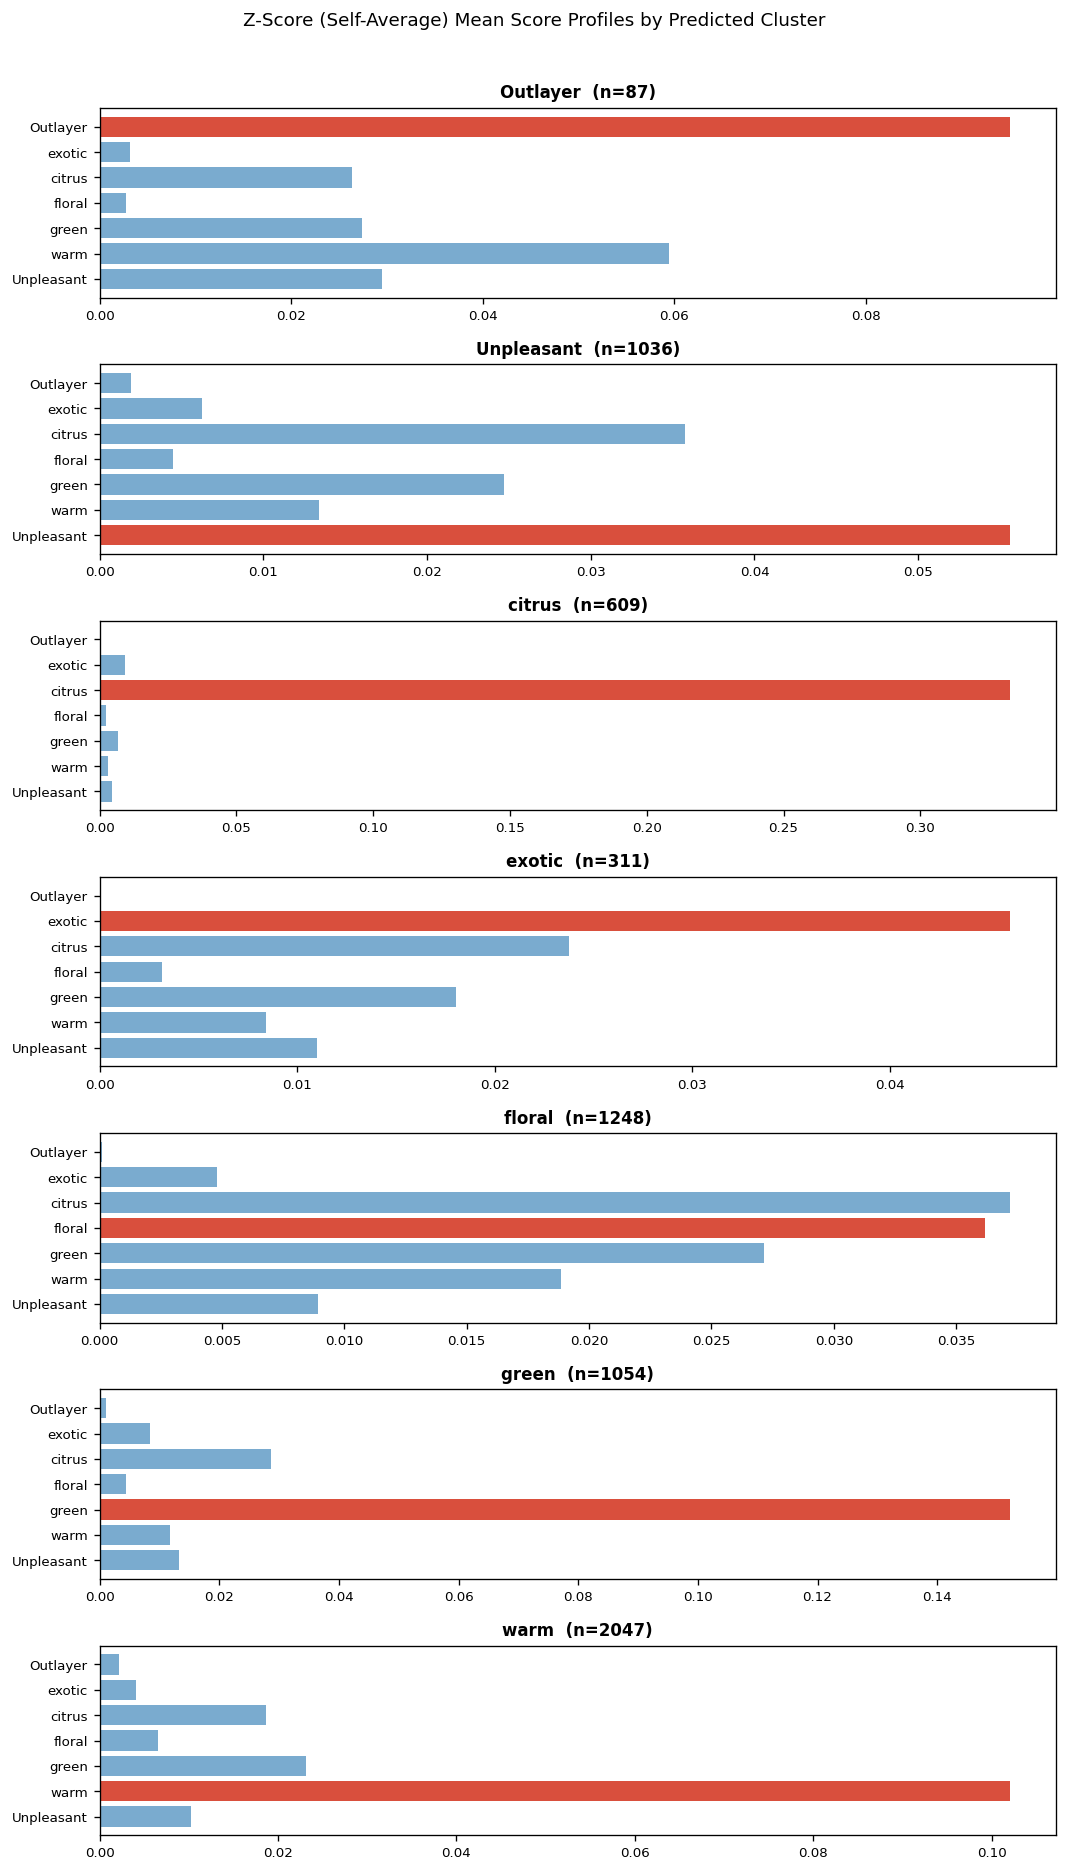

Saved: ../outputs/fourth_trial_score_profiles_avg.png


In [13]:
scores_avg_norm = normalize_scores(scores_avg)
profile_avg = scores_avg_norm.copy()
profile_avg["cluster"] = ms_avg
mean_profile_avg = profile_avg.groupby("cluster")[CLUSTER_COLS].mean()

fig, axes = plt.subplots(len(mean_profile_avg), 1,
                         figsize=(9, 2.2 * len(mean_profile_avg)), sharey=False)
if len(mean_profile_avg) == 1:
    axes = [axes]

for ax, (cluster, row) in zip(axes, mean_profile_avg.iterrows()):
    n = (ms_avg == cluster).sum()
    colors = ["#d94f3d" if c == cluster else "#7aabcf" for c in CLUSTER_COLS]
    ax.barh(CLUSTER_COLS, row[CLUSTER_COLS], color=colors)
    ax.set_xlim(0, None)
    ax.set_title(f"{cluster}  (n={n})", fontsize=10, fontweight="bold")
    ax.tick_params(axis="both", labelsize=8)

fig.suptitle("Z-Score (Self-Average) Mean Score Profiles by Predicted Cluster",
             fontsize=11, y=1.01)
plt.tight_layout()
out_avg = Path("../outputs/fourth_trial_score_profiles_avg.png")
plt.savefig(out_avg, bbox_inches="tight")
plt.show()
print(f"Saved: {out_avg}")


## 13. Z-Score with Self-Median

In [14]:
recipes_med  = apply_zscore_quantities(recipes, median_self)
scores_med   = compute_scores(recipes_med, weights)
ms_med       = assign_clusters(scores_med)
ms_med_panel = ms_med.map(MS_TO_PANEL)

print("Cluster distribution (Z-Score, self median):")
print(ms_med.value_counts().to_string())


Cluster distribution (Z-Score, self median):
MS_cluster
warm          1847
floral        1543
Unpleasant    1103
green          852
citrus         622
exotic         294
Outlayer       131


## 14. Score Profiles per Cluster (Self-Median Z-Score)

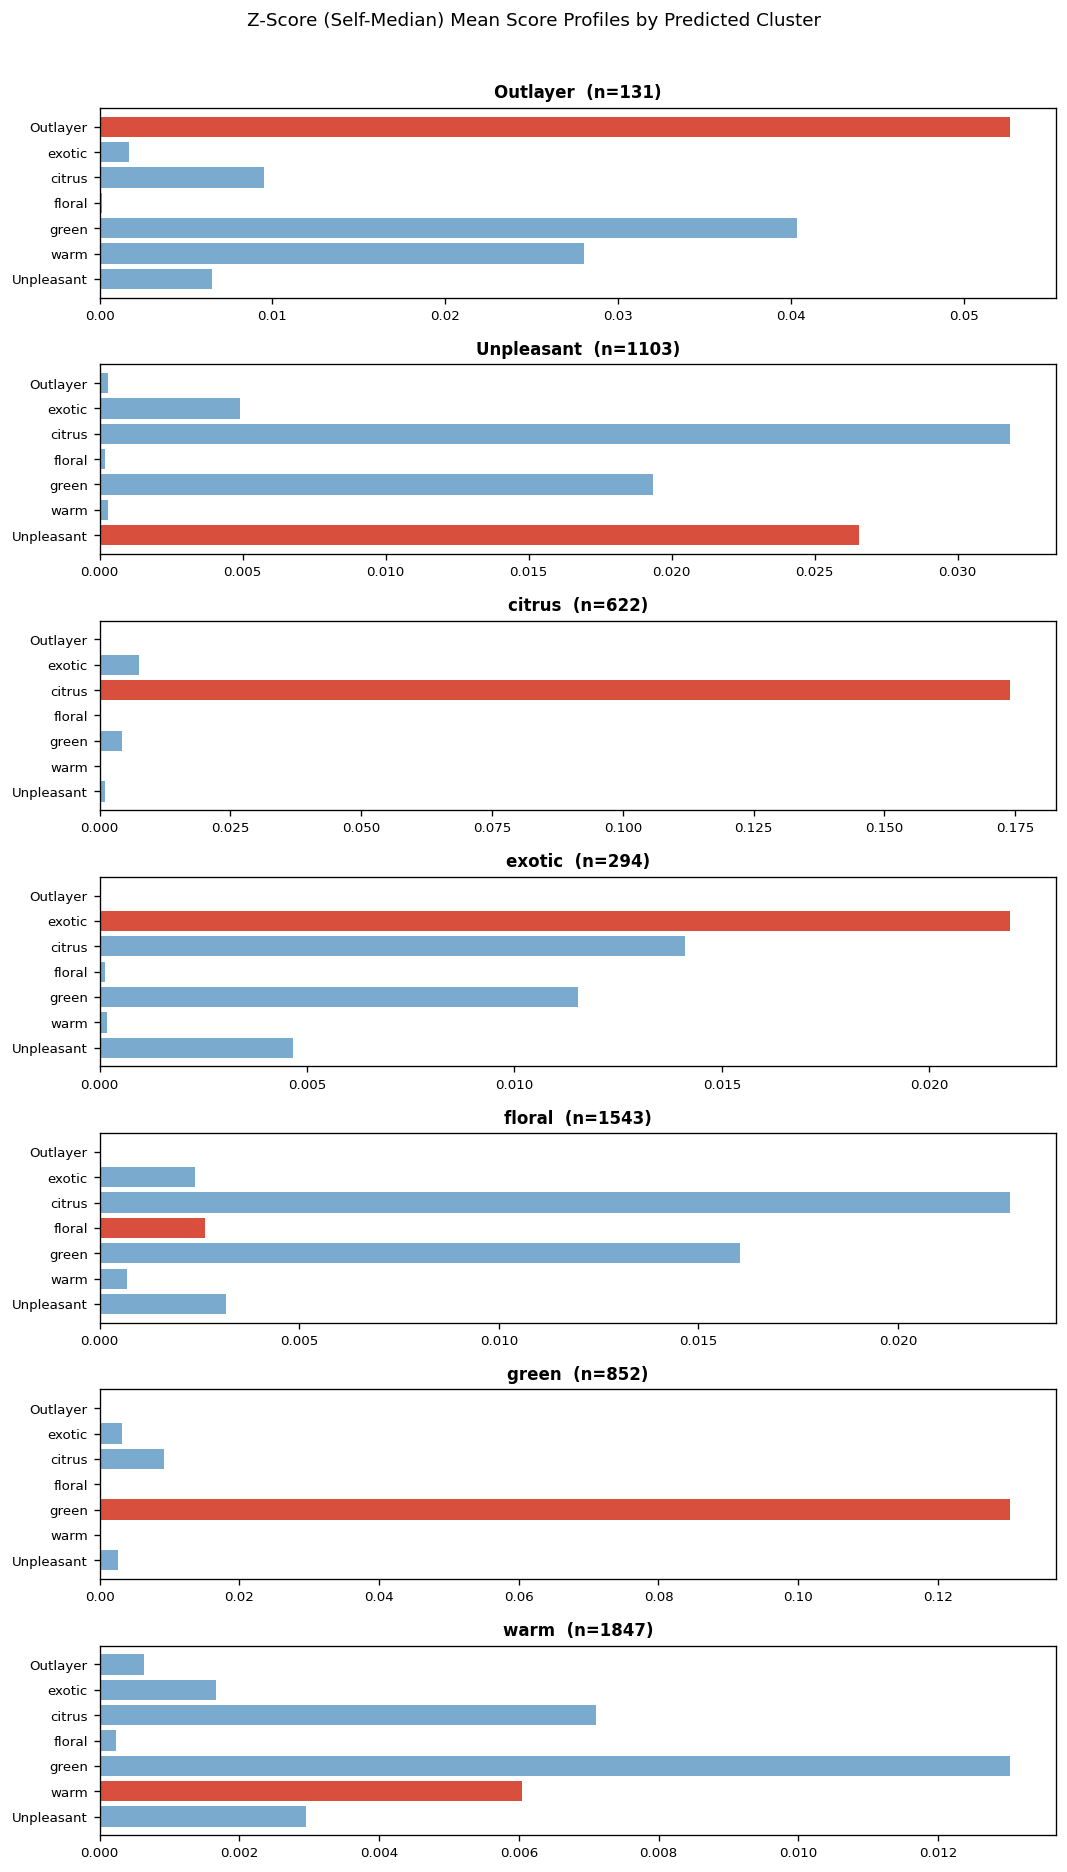

Saved: ../outputs/fourth_trial_score_profiles_median.png


In [15]:
scores_med_norm = normalize_scores(scores_med)
profile_med = scores_med_norm.copy()
profile_med["cluster"] = ms_med
mean_profile_med = profile_med.groupby("cluster")[CLUSTER_COLS].mean()

fig, axes = plt.subplots(len(mean_profile_med), 1,
                         figsize=(9, 2.2 * len(mean_profile_med)), sharey=False)
if len(mean_profile_med) == 1:
    axes = [axes]

for ax, (cluster, row) in zip(axes, mean_profile_med.iterrows()):
    n = (ms_med == cluster).sum()
    colors = ["#d94f3d" if c == cluster else "#7aabcf" for c in CLUSTER_COLS]
    ax.barh(CLUSTER_COLS, row[CLUSTER_COLS], color=colors)
    ax.set_xlim(0, None)
    ax.set_title(f"{cluster}  (n={n})", fontsize=10, fontweight="bold")
    ax.tick_params(axis="both", labelsize=8)

fig.suptitle("Z-Score (Self-Median) Mean Score Profiles by Predicted Cluster",
             fontsize=11, y=1.01)
plt.tight_layout()
out_med = Path("../outputs/fourth_trial_score_profiles_median.png")
plt.savefig(out_med, bbox_inches="tight")
plt.show()
print(f"Saved: {out_med}")


## 15. Four-Method Comparison

In [16]:
comparison = pd.DataFrame({
    "Raw MS":        ms_raw.value_counts(),
    "Z-Score Meli":  ms_z.value_counts(),
    "Z-Score Avg":   ms_avg.value_counts(),
    "Z-Score Median":ms_med.value_counts(),
}).fillna(0).astype(int).sort_index()

print("Cluster assignment counts across all four methods:")
print(comparison.to_string())
print()
print("Row totals (should all equal 6392):")
print(comparison.sum().to_string())


Cluster assignment counts across all four methods:
            Raw MS  Z-Score Meli  Z-Score Avg  Z-Score Median
MS_cluster                                                   
Outlayer        85           177           87             131
Unpleasant     765           688         1036            1103
citrus         756           608          609             622
exotic         460           235          311             294
floral         896          2258         1248            1543
green         1034           863         1054             852
warm          2396          1563         2047            1847

Row totals (should all equal 6392):
Raw MS            6392
Z-Score Meli      6392
Z-Score Avg       6392
Z-Score Median    6392


## 16. Export Self-Referencing Predictions

In [17]:
with pd.ExcelWriter(OUT_XLSX, engine="openpyxl", mode="a", if_sheet_exists="replace") as writer:
    # Self-avg
    pred_avg = pd.DataFrame({
        "ZScore_Avg_cluster":    ms_avg,
        "ZScore_Avg_panel_name": ms_avg_panel,
    }).join(scores_avg.round(4).add_prefix("Score_"))
    pred_avg.sort_values("ZScore_Avg_cluster").to_excel(writer, sheet_name="ZScore_Avg_All")
    pred_avg[["ZScore_Avg_cluster", "ZScore_Avg_panel_name"]].rename_axis("Recipe").to_excel(
        writer, sheet_name="ZScore_Avg_Slim")

    # Self-median
    pred_med = pd.DataFrame({
        "ZScore_Med_cluster":    ms_med,
        "ZScore_Med_panel_name": ms_med_panel,
    }).join(scores_med.round(4).add_prefix("Score_"))
    pred_med.sort_values("ZScore_Med_cluster").to_excel(writer, sheet_name="ZScore_Med_All")
    pred_med[["ZScore_Med_cluster", "ZScore_Med_panel_name"]].rename_axis("Recipe").to_excel(
        writer, sheet_name="ZScore_Med_Slim")

    # Comparison summary
    comparison.to_excel(writer, sheet_name="Method_Comparison")

print(f"Added to {OUT_XLSX}:")
for s in ["ZScore_Avg_All", "ZScore_Avg_Slim", "ZScore_Med_All", "ZScore_Med_Slim", "Method_Comparison"]:
    print(f"  {s}")


Added to ../outputs/scoring_fourth_trial.xlsx:
  ZScore_Avg_All
  ZScore_Avg_Slim
  ZScore_Med_All
  ZScore_Med_Slim
  Method_Comparison


## 17. Cluster Profile Grid (7 clusters x 4 methods)

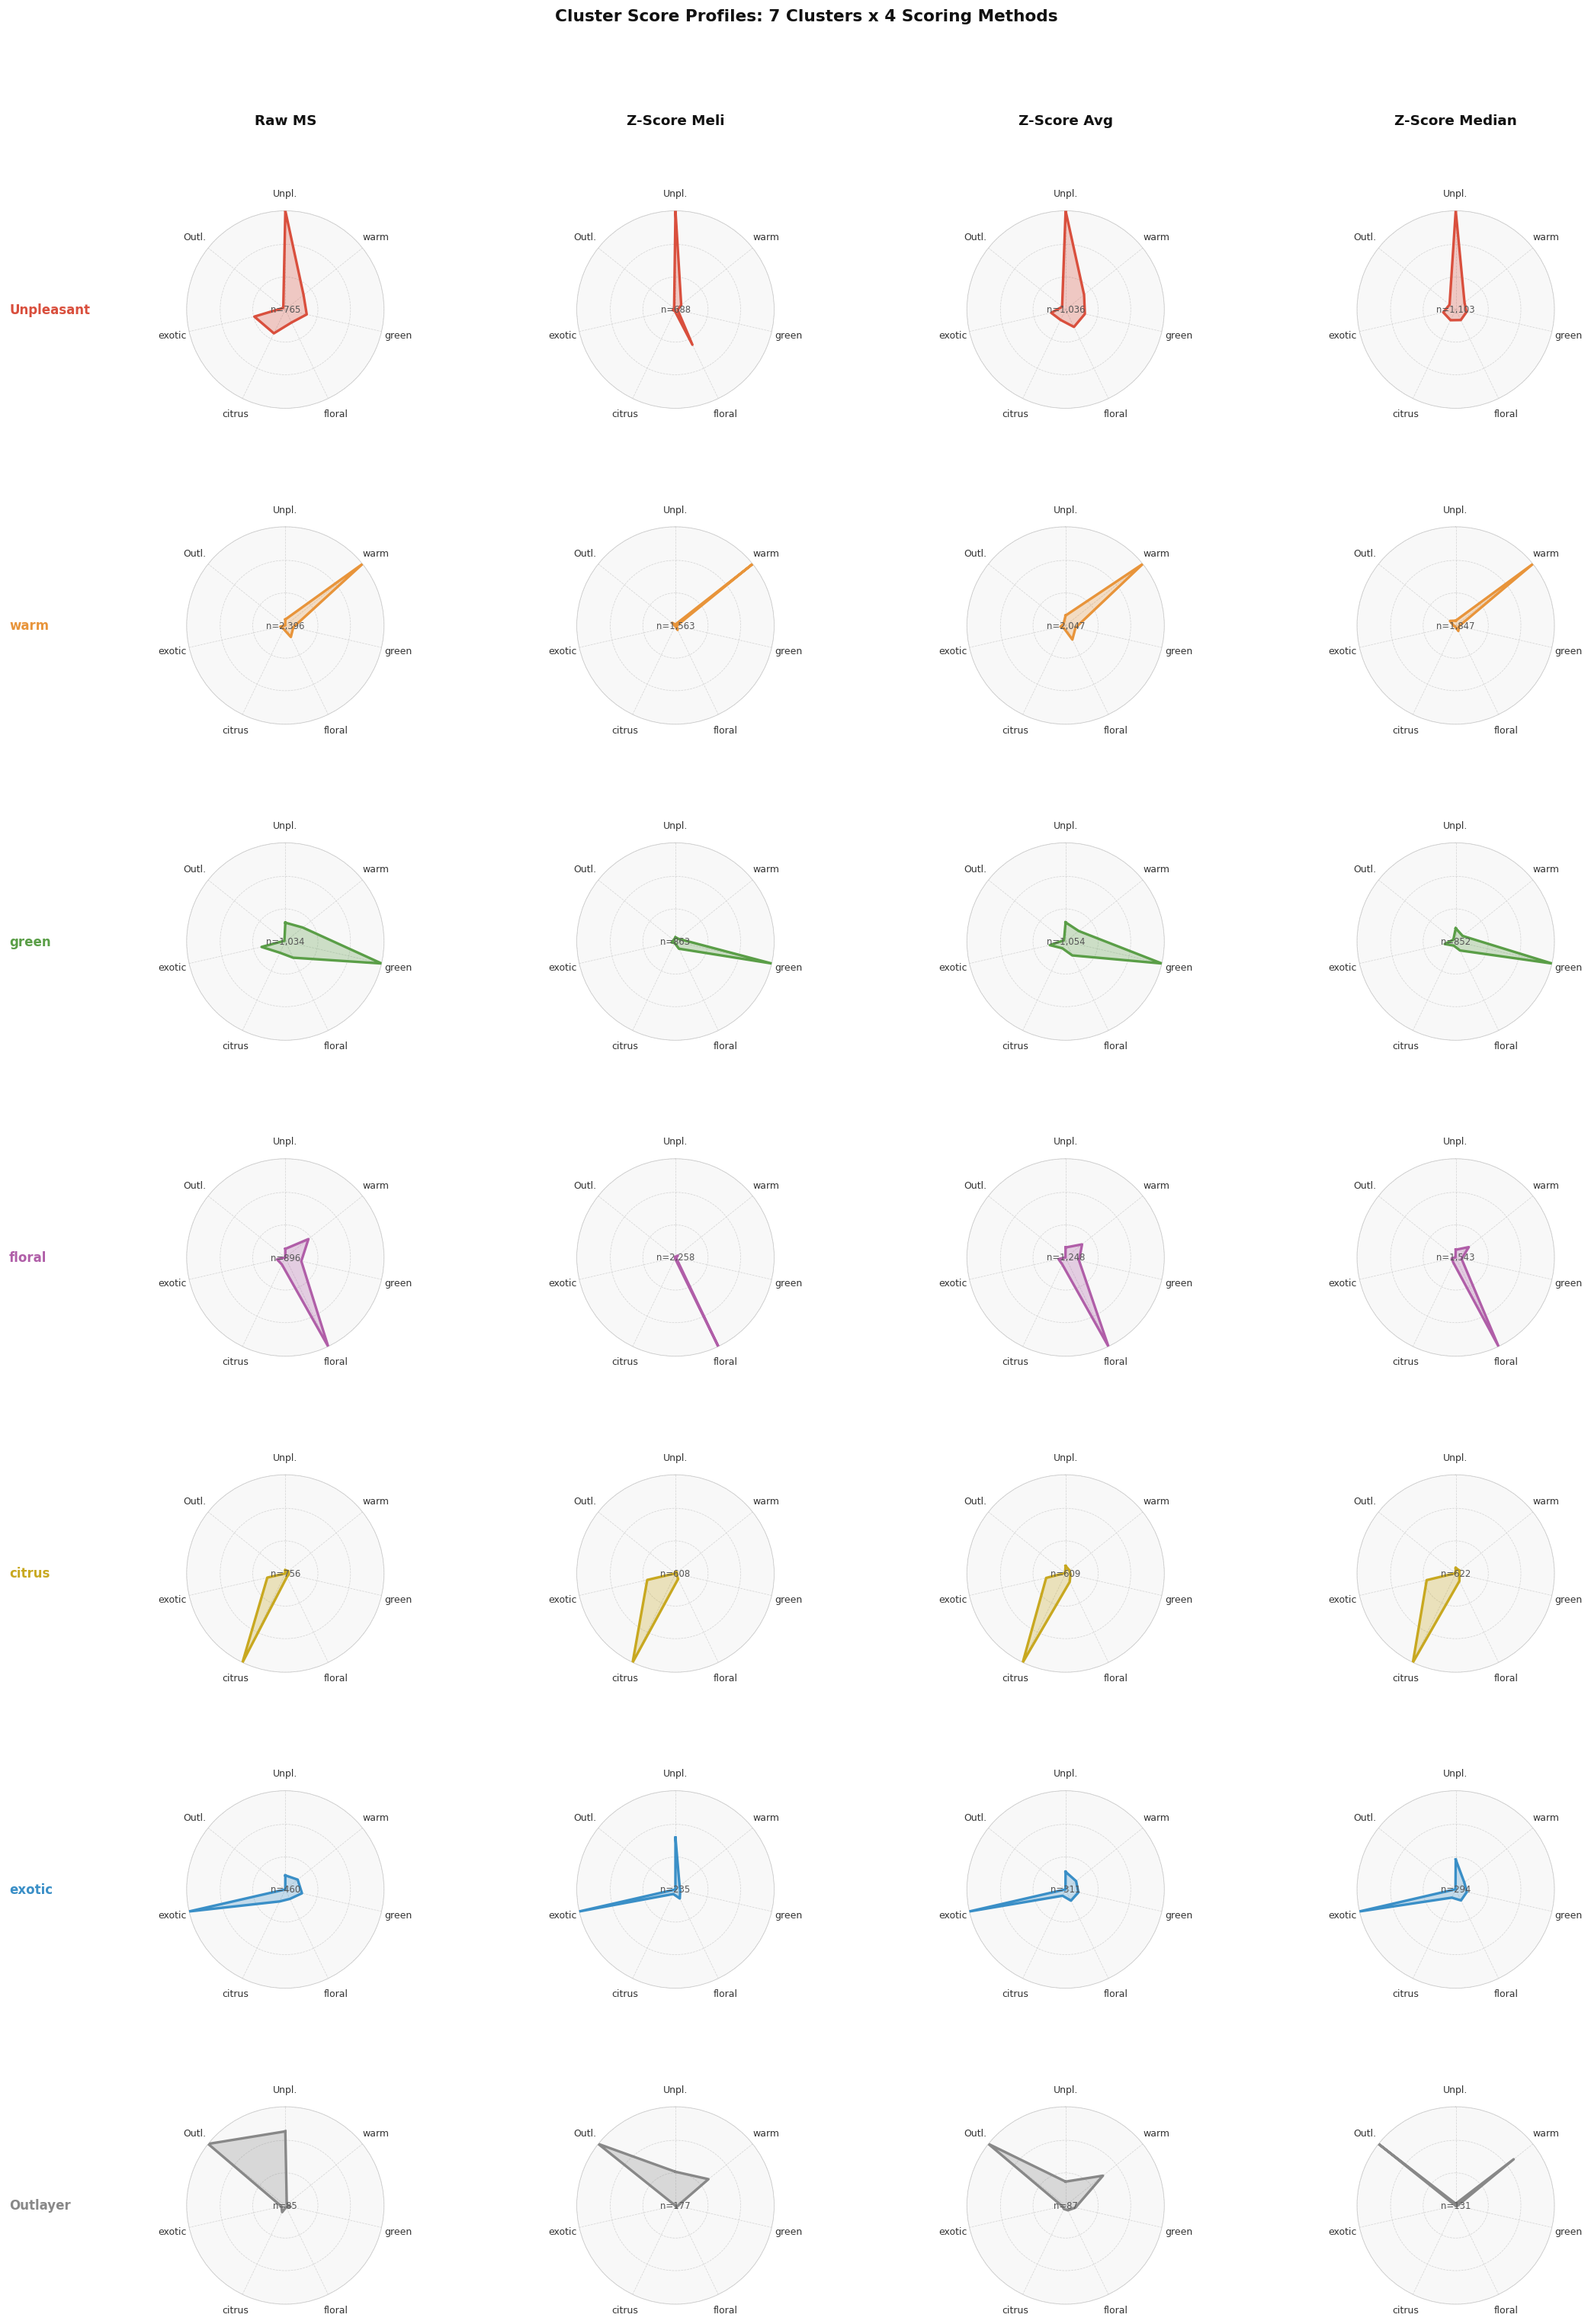

Saved: ../outputs/fourth_trial_cluster_profile_grid.png


In [18]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

METHODS = [
    ("Raw MS",          ms_raw,  scores_ms),
    ("Z-Score Meli",    ms_z,    scores_z),
    ("Z-Score Avg",     ms_avg,  scores_avg),
    ("Z-Score Median",  ms_med,  scores_med),
]

CLUSTERS_ORDER = ["Unpleasant", "warm", "green", "floral", "citrus", "exotic", "Outlayer"]

CLUSTER_COLORS = {
    "Unpleasant": "#d94f3d",
    "warm":       "#e8943a",
    "green":      "#5a9e47",
    "floral":     "#b05ea8",
    "citrus":     "#c8a820",
    "exotic":     "#3a8fc7",
    "Outlayer":   "#888888",
}

RADAR_LABELS = ["Unpl.", "warm", "green", "floral", "citrus", "exotic", "Outl."]
N_AXES = len(CLUSTER_COLS)
angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles_closed = angles + [angles[0]]

def draw_radar(ax, values, color, n_recipes):
    # Normalize each chart to its own max so the shape always fills the space
    vmax = values.max() if values.max() > 0 else 1.0
    v_norm = values / vmax
    v = list(v_norm) + [v_norm[0]]
    ax.plot(angles_closed, v, color=color, linewidth=2.0, zorder=3)
    ax.fill(angles_closed, v, color=color, alpha=0.28, zorder=2)
    ax.set_xticks(angles)
    ax.set_xticklabels(RADAR_LABELS, size=7.5, color="#333333")
    ax.set_ylim(0, 1)
    ax.set_yticks([0.33, 0.66, 1.0])
    ax.set_yticklabels([], size=0)
    ax.tick_params(axis="x", pad=3)
    ax.grid(color="#cccccc", linestyle="--", linewidth=0.45, alpha=0.8)
    ax.spines["polar"].set_linewidth(0.5)
    ax.spines["polar"].set_color("#cccccc")
    ax.text(0, 0, f"n={n_recipes:,}", ha="center", va="center",
            fontsize=7, color="#555555")

# Pre-compute mean raw score per method x cluster (no global normalization)
profiles = {}
for method_name, ms_series, scores_df in METHODS:
    df = scores_df.copy()
    df["cluster"] = ms_series
    profiles[method_name] = df.groupby("cluster")[CLUSTER_COLS].mean()

n_rows = len(CLUSTERS_ORDER)
n_cols = len(METHODS)

fig = plt.figure(figsize=(n_cols * 4.4, n_rows * 3.6 + 0.8))
fig.patch.set_facecolor("white")

# Reserve top space for title + col headers separately
gs = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                       hspace=0.60, wspace=0.40,
                       top=0.90, bottom=0.02, left=0.09, right=0.99)

# Column headers as fig.text above the grid
for col_idx, (method_name, _, _) in enumerate(METHODS):
    col_center = gs[0, col_idx].get_position(fig).x0 + gs[0, col_idx].get_position(fig).width / 2
    fig.text(col_center, 0.935, method_name,
             ha="center", va="bottom",
             fontsize=11, fontweight="bold", color="#111111")

for col_idx, (method_name, ms_series, _) in enumerate(METHODS):
    for row_idx, cluster in enumerate(CLUSTERS_ORDER):
        ax = fig.add_subplot(gs[row_idx, col_idx], projection="polar")
        ax.set_theta_offset(np.pi / 2)
        ax.set_theta_direction(-1)
        ax.set_facecolor("#f8f8f8")

        color  = CLUSTER_COLORS[cluster]
        n_rec  = int((ms_series == cluster).sum())
        mean_p = profiles[method_name]

        vals = (mean_p.loc[cluster, CLUSTER_COLS].values.astype(float)
                if cluster in mean_p.index else np.zeros(N_AXES))

        draw_radar(ax, vals, color, n_rec)

        # Row label left of first column
        if col_idx == 0:
            pos = ax.get_position()
            fig.text(0.005,
                     pos.y0 + pos.height * 0.5,
                     cluster,
                     va="center", ha="left",
                     fontsize=10, fontweight="bold",
                     color=color)

fig.suptitle("Cluster Score Profiles: 7 Clusters x 4 Scoring Methods",
             fontsize=13, fontweight="bold", y=0.985, color="#111111")

out_grid = Path("../outputs/fourth_trial_cluster_profile_grid.png")
plt.savefig(out_grid, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {out_grid}")


## Findings: Four-Method Comparison

```
            Raw MS  Z-Score Meli  Z-Score Avg  Z-Score Median
Outlayer        85           177           87             131
Unpleasant     765           688         1036            1103
citrus         756           608          609             622
exotic         460           235          311             294
floral         896          2258         1248            1543
green         1034           863         1054             852
warm          2396          1563         2047            1847
```

### Key observations

**Z-Score Meli inflates floral strongly**
Z-Score Meli assigns 35% of all recipes to floral (2,258) versus only 14% for Raw MS (896).
Melanie's 9 reference recipes are all strawberry formulas, which typically contain high
concentrations of floral ingredients. This pushes the AvgMeli baseline for floral CAS
very high, so even a moderate floral ingredient use looks modest by comparison. For
non-strawberry recipes this calibration does not apply and causes over-assignment to floral.

**Self-referencing methods sit between Raw MS and Z-Score Meli**
Both self-avg and self-median produce more balanced distributions than Z-Score Meli
because the baseline reflects the full diversity of the dataset, not a narrow strawberry
reference.

**Average vs Median: median amplifies Unpleasant and floral, damps warm**
The median baseline is lower than the mean for most CAS because a few recipes use
ingredients at very high concentrations (long tail in the distribution). A lower baseline
means the Z-Score for a typical usage is higher, which amplifies cluster differences.
The net effect: median pushes 200 more recipes from warm into floral and Unpleasant
compared to the mean.

**Citrus and exotic are stable across all methods**
Citrus (608-756) and exotic (235-460) show the smallest relative variation.
These clusters contain highly distinctive CAS with limited cross-cluster weights,
so the choice of calibration method has little effect on their assignment.

**Outlayer remains a small cluster**
Outlayer stays between 85 and 177 regardless of method, suggesting that the recipes
assigned there have a consistently distinctive profile that no calibration approach
reassigns elsewhere.

### Recommendation

For exploratory analysis of the Fourth Trial Set, **Z-Score Self-Median** is the most
defensible choice: it uses the full dataset as its own reference, covers 94.5% of CAS,
and is robust to high-concentration outliers that can distort the mean. Z-Score Meli
is best reserved for direct comparison with Melanie's original strawberry clustering,
where its calibration is appropriate.
